# ASTRA — 粒子追踪模拟器

本 Notebook 是独立的 ASTRA 粒子追踪模拟工具，用于调用 **ASTRA** 程序对粒子分布进行传输模拟。

- **可独立使用**：加载任意 `.ini` 分布文件（不依赖 Generator）
- **可搭配 Generator**：使用 `generator_interface.ipynb` 生成的 `bunch.ini` 作为输入
- **支持对比分析**：可选加载初始分布文件，与追踪结果进行对比

依次运行所有单元格即可完成：参数设置 → 运行 ASTRA → 读取相空间 → 统计分析与可视化。

## Initialization

In [15]:
# 初始化：导入工具模块 & 环境检测

import utils
import platform
from pathlib import Path

# ---- 工作目录 ----
PROJECT_DIR = Path.cwd().resolve()
SIM_DIR = PROJECT_DIR / "simulation_files"
SIM_DIR.mkdir(parents=True, exist_ok=True)

utils.logger.info(f"项目目录 (PROJECT_DIR): {PROJECT_DIR}")
utils.logger.info(f"工作目录 (SIM_DIR):     {SIM_DIR}")

# ---- 系统版本 ----
OS_VERSION = f"{platform.system()} {platform.release()} ({platform.mac_ver()[0] or 'N/A'})"

# ---- 检测 ASTRA 可执行文件 ----
ASTRA_EXE = utils.check_executable("astra", fallback_dir=PROJECT_DIR)
ASTRA_VERSION = utils.get_version(ASTRA_EXE, SIM_DIR)

utils.logger.info("环境检测通过，可以开始 ASTRA 模拟。")

# ---- 环境汇总 ----
utils.print_environment_header(
    tool_name="ASTRA",
    tool_version=ASTRA_VERSION,
    sim_dir=SIM_DIR,
    os_version=OS_VERSION,
)

INFO: 项目目录 (PROJECT_DIR): /Users/yuxinwu/astra_notebook
INFO: 工作目录 (SIM_DIR):     /Users/yuxinwu/astra_notebook/simulation_files
INFO: ✓ 在 PATH 中找到 astra: /Users/yuxinwu/ASTRA/astra
INFO: 环境检测通过，可以开始 ASTRA 模拟。



  ASTRA 初始化完成 — 2026-07-06 01:14:04
  操作系统             Darwin 25.5.0 (26.5.1)
  ASTRA                Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
  工作目录             /Users/yuxinwu/astra_notebook/simulation_files
  首选解析器           ocelot



## ASTRA Input

ASTRA 使用多个 namelist 模块。有两种方式提供输入参数：

1. **使用现有 `.in` 文件**（推荐直接导入已有配置）：设置 `USE_EXISTING_ASTRA_INPUT = True`，指定 `EXISTING_ASTRA_INPUT_FILE` 路径
2. **通过 Python 字典生成**（默认）：修改下方各字典即可调整模拟参数，自动生成 `astra.in`

**重要**：`Distribution` 指定初始分布文件路径，可以：
- 使用 Generator 生成的 `bunch.ini`
- 指定任意其他 `.ini` 格式的粒子分布文件
- 使用相对于 `SIM_DIR` 的路径或绝对路径

In [16]:
# ASTRA 输入参数

# ---- 输入模式切换 ----
# True=导入现有 .in 文件, False=下方字典自动生成（默认）
USE_EXISTING_ASTRA_INPUT = True

# ---- 模式 A：使用现有 .in 文件（USE_EXISTING_ASTRA_INPUT=True 时生效）----
EXISTING_ASTRA_INPUT_FILE = SIM_DIR / "Example.in"  # Aperture 示例

# ---- 模式 B 通用设置 ----
DISTRIBUTION_FILE = str(SIM_DIR / "Example.ini")  # 初始分布文件
REF_ENERGY_MEV = None                            # 参考能量 [MeV]，None=自动检测
USE_CHARGE = False                                # 空间电荷开关，F=不写入 &CHARGE namelist
USE_SCAN = False                                  # 参数扫描开关，T=启用 &SCAN namelist
USE_CAVITY = False                                # 加速腔模式开关，T=启用 &CAVITY namelist
USE_SOLENOID = False                              # 螺线管模式开关，T=启用 &SOLENOID namelist
USE_WAKE = False                                  # 尾场模式开关，T=启用 &WAKE namelist
USE_APERTURE = True                               # 孔径模式开关，T=启用 &APERTURE namelist

# ============================================================
# 模式 B：Python 字典生成 astra.in（USE_EXISTING_ASTRA_INPUT=False 时生效）
# 参数说明基于 ASTRA 手册，按手册顺序排列
# ============================================================

# -- &NEWRUN --
astra_newrun_params = {
    "Head": "'Aperture test - circular + beam stop'",   # 运行标题（最多 80 字符）
    "RUN": 1,                                          # 运行编号，用于输出文件后缀
    "Loop": False,                                     # 启用循环模式标志
    "Nloop": 1,                                        # 循环迭代次数
    "Distribution": f"'{DISTRIBUTION_FILE}'",          # 粒子分布文件名
    "Xoff": 0.0,                                       # 参考粒子水平偏移 [m]
    "Yoff": 0.0,                                       # 参考粒子垂直偏移 [m]
    "Track_All": True,                                 # 追踪所有粒子标志（含探针粒子）
    "Phase_Scan": False,                               # 扫描腔相位标志
    "Auto_Phase": True,                                # 自动计算腔相位标志
    "check_ref_part": False,                           # 检查参考粒子标志
    "H_max": 0.001,                                    # Runge-Kutta 积分最大步长 [m]
    "H_min": 0.0,                                      # Runge-Kutta 积分最小步长 [m]
}

# -- &OUTPUT --
astra_output_params = {
    # -- 输出范围 --
    "ZSTART": 0.0,                                     # 输出生成起始 z 位置 [m]
    "ZSTOP": 0.25,                                     # 追踪终止 z 位置 [m]（超出孔径区域）
    "Zemit": 500,                                      # 发射度输出间隔数
    "Zphase": 1,                                       # 相空间输出间隔数
    # -- 屏幕输出 --
    "Screen(1)": 0.1,                                      # 额外输出位置列表 [m]
    "Screen(2)": 0.2,                                     # 额外输出位置列表 [m]
    "Scr_xrot": [],                                    # 屏幕绕 x-z 平面旋转角 [rad]
    "Scr_yrot": [],                                    # 屏幕绕 y-z 平面旋转角 [rad]
    # -- 步长输出控制 --
    "Step_width": 0,                                   # 基于步数输出间隔，0=关闭
    "Step_max": 0,                                     # 基于步数输出的终止步数
    # -- 发射度计算选项 --
    "Lproject_emit": False,                            # 投影发射度
    "Local_emit": False,                               # 局部发射度
    "Lmagnetized": False,                              # 磁化束团发射度
    "Lsub_rot": False,                                 # 扣除角动量
    "Lsub_Larmor": False,                              # 扣除 Larmor 旋转
    "Lsub_coup": False,                                # 扣除耦合
    "Rot_ang": 0.0,                                    # 发射度计算旋转角 [rad]
    "Lsub_cor": False,                                 # 扣除后发射度
    # -- 输出开关 --
    "RefS": True,                                      # 参考粒子轨迹 (astra.ref.NNN)
    "EmitS": True,                                     # 发射度信息 (astra.Xemit.NNN)
    "C_EmitS": False,                                  # 100% 发射度
    "C99_EmitS": False,                                # 99% 发射度
    "Tr_EmitS": False,                                 # 截断发射度
    "Sub_EmitS": False,                                # 子束团发射度
    "Cross_start": 0.0,                                # crossover 检测起始点 [m]
    "Cross_end": 0.0,                                  # crossover 检测终止点 [m]
    "PhaseS": True,                                    # 相空间分布 (astra.NNNN.RRR)
    "T_PhaseS": False,                                 # 时间基准相空间
    "High_res": False,                                 # 高精度输出
    "Binary": False,                                   # 二进制输出
    "TrackS": False,                                   # 所有粒子轨迹
    "TcheckS": False,                                  # 时间检查
    "SigmaS": True,                                    # RMS 束团参数
    "CathodeS": False,                                 # 阴极信息
    "LandFS": False,                                   # Landau 阻尼信息
    "LarmorS": False,                                  # Larmor 旋转信息
}

# -- &CHARGE --
astra_charge_params = {
    # -- 空间电荷开关 --
    "LOOP": False,                                     # 空间电荷参数扫描循环标志
    "LSPCH": False,                                    # 包含空间电荷力标志
    "LSPCH3D": False,                                  # 3D 空间电荷标志
    "L2D_3D": False,                                   # 2D→3D 自动切换标志
    # -- 镜像电荷 --
    "Lmirror": True,                                   # 阴极镜像电荷标志
    "L_Curved_Cathode": False,                         # 弯曲阴极修正标志
    "Cathode_Contour": "",                             # 阴极轮廓文件名
    "R_zero": 0.0,                                     # 弯曲阴极轴上曲率半径 [m]
    # -- 柱坐标网格（2D）--
    "Nrad": 10,                                        # 径向网格单元数
    "Cell_var": 2.0,                                   # 径向单元尺寸变化参数
    "Nlong_in": 10,                                    # 纵向最大网格单元数
    "N_min": 30,                                       # 阴极发射每步平均粒子数
    "min_grid": 0.0,                                   # 最小网格长度 [m]
    # -- 网格合并 --
    "Merge_1": 0, "Merge_2": 0, "Merge_3": 0, "Merge_4": 0, "Merge_5": 0,
    "Merge_6": 0, "Merge_7": 0, "Merge_8": 0, "Merge_9": 0, "Merge_10": 0,
    # -- 2D→3D 切换 --
    "z_trans": 0.0,                                    # 2D→3D 切换位置 [m]
    "min_grid_trans": 0.0,                             # 切换过程中最小 2D 网格长度 [m]
    # -- 3D 网格（FFT 算法）--
    "Nxf": 8, "Nx0": 2, "Nyf": 8, "Ny0": 2, "Nzf": 8, "Nz0": 2,
    # -- 3D 平滑 --
    "Smooth_x": 0, "Smooth_y": 0, "Smooth_z": 0,
    # -- 缩放控制 --
    "Max_scale": 0.05,                                 # 最大网格缩放因子
    "Max_count": 40,                                   # 空间电荷场缩放最大次数
    "Exp_control": 0.1,                                # 束团尺寸-网格比变化容忍度
}

# -- &SCAN --
astra_scan_params = {
    "LOOP": False,                                     # 循环控制
    "LScan": False,                                    # 扫描总开关，T=执行参数扫描
    "LExtend": False,                                  # T=扩展已有扫描输出文件，F=覆盖
    "Scan_para": "",                                   # 待扫描的参数名（斜体列出的参数）
    "S_min": 0.0,                                      # 扫描参数最小值
    "S_max": 0.0,                                      # 扫描参数最大值
    "S_numb": 0,                                       # 扫描点数
    # -- 优化选项 --
    "O_min": False,                                    # T=在缩小区间内搜索 FOM(1) 最小值
    "O_max": False,                                    # T=在缩小区间内搜索 FOM(1) 最大值
    "O_match": False,                                  # T=将 FOM(1) 匹配到 match_value
    "match_value": 0.0,                                # O_match 时的匹配目标值
    "O_depth": 0,                                      # 优化深度，总运行次数约 S_numb·O_depth
    # -- 区间最值搜索 --
    "L_min": False,                                    # T=在 S_zmin~S_zmax 保存 FOM(1) 最小值
    "L_max": False,                                    # T=在 S_zmin~S_zmax 保存 FOM(1) 最大值
    "S_zmin": 0.0,                                     # 最值搜索起始 z 位置 [m]
    "S_zmax": 0.0,                                     # 最值搜索终止 z 位置 [m]
    "S_dz": 0,                                         # S_zmin~S_zmax 等分间隔数
    # -- 输出量 --
    "FOM": [],                                         # 品质因数列表，如 'bunch charge', 'horizontal rms emittance' 等
}

# -- &CAVITY --
astra_cavity_params = {
    # -- 腔场开关 --
    "LOOP": False,                                     # 循环控制
    "LEfield": False,                                  # 腔场总开关，F=关闭所有腔
    # -- 场表/场图输入 --
    "File_Efield": [],                                 # 场表/场图文件名，或关键字 'plasma'
    "C_noscale": [],                                   # T=不缩放场，直接使用文件值 [MV/m] 或 [T]
    "C_smooth": [],                                    # 场表平滑迭代次数
    "Com_grid": [],                                    # 3D 场图公共网格: 'E,B' 或 'all'
    "C_higher_order": [],                              # T=场展开到 3 阶, F=1 阶（不适用于 TWS）
    # -- RF 参数 --
    "Nue": [],                                         # RF 频率 [GHz]
    "K_wave": [],                                      # 波数 [m⁻¹]，仅用于 β 匹配行波结构
    "MaxE": [],                                        # 最大轴上场强 [MV/m]（TM）或 [T]（TE）
    "Ex_stat": [], "Ey_stat": [],                      # 将 MaxE 重定向到横向电场分量（DC 场）
    "Bx_stat": [], "By_stat": [], "Bz_stat": [],       # 将 MaxE 重定向到横向磁场分量（静磁场）
    # -- 场修正 --
    "Flatness": [],                                    # 场平坦度修正（线性斜率），不适用于 3D/TWS
    "Phi": [],                                         # RF 相位 [deg]，Phi(0) 定义全局相位偏移
    "C_pos": [],                                       # 腔纵向位置偏移 [m]
    "C_numb": [],                                      # TWS 周期数（不含输入/输出耦合器）或 3D 场图重复次数
    # -- 时变场 / 束流负载 --
    "T_dependence": [],                                # 'fill' 或 'decay'，腔场充/放电
    "T_null": [],                                      # 充/放电开始到粒子追踪开始的时间 [ns]
    "C_Tau": [],                                       # 腔填充时间 [ns]
    "E_stored": [],                                    # 腔储能 [J·m²/MV²]，指定后计算束流负载
    # -- 腔对准 --
    "C_xoff": [], "C_yoff": [],                        # 腔横向偏移 [m]
    "C_xrot": [], "C_yrot": [], "C_zrot": [],          # 腔旋转角 [rad]
}

# -- &SOLENOID --
astra_solenoid_params = {
    # -- 螺线管开关 --
    "Loop": False,                                     # 循环控制
    "LBField": True,                                   # 螺线管磁场总开关，F=关闭所有螺线管
    # -- 场文件输入 --
    "File_Bfield(1)": "'Solenoid.dat'",                # 螺线管场文件名（1D 场表）
    "S_smooth(1)": 10,                                 # 场表平滑迭代次数
    # -- 场参数 --
    "MaxB(1)": 0.35,                                   # 最大轴上磁场 [T]
    # -- 螺线管位置与对准 --
    "S_pos(1)": 1.2,                                   # 螺线管纵向位置 [m]
    "S_noscale": [],                                   # T=不缩放场，直接使用文件值 [T]
    "S_higher_order": [],                              # T=场展开到 3 阶，F=1 阶
    "S_xoff": [], "S_yoff": [],                        # 螺线管横向偏移 [m]
    "S_xrot": [], "S_yrot": [],                        # 螺线管绕 x/y 轴旋转角 [rad]
}

# -- &WAKE --
astra_wake_params = {
    # -- 尾场开关 --
    "Loop": False,                                     # 循环控制
    "LWAKE": False,                                    # 尾场总开关，F=忽略所有 &WAKE
    # -- 尾场输入文件 --
    "Wk_Type": [],                                     # 尾场类型
    "Wk_filename": [],                                 # 尾场数据文件名
    "Wk_testfile": [],                                 # 测试输出文件名
    # -- 尾场选项 --
    "Wk_screen": [],                                   # T=kick 后保存相空间
    "Wk_scaling": 1.0,                                 # 尾场缩放因子
    # -- 尾场位置 --
    "Wk_x": [], "Wk_y": [],                            # 尾场横向原点 [m]
    "Wk_z": [],                                        # 尾场纵向位置 [m]
    "Wk_ex": [], "Wk_ey": [], "Wk_ez": [],             # 纵向方向向量
    "Wk_hx": [], "Wk_hy": [], "Wk_hz": [],             # 横向方向向量
    # -- 分 bin 与插值 --
    "Wk_equi_grid": [],                                # 1.0=等距网格, 0.0=等电荷网格
    "Wk_N_bin": [],                                    # bin 数量
    "Wk_ip_method": [],                                # 插值方法
    "Wk_smooth": [],                                   # 高斯插值平滑参数
    "Wk_sigma_min": [],                                # 高斯插值最小 sigma
    "Wk_sub": [],                                      # 子 bin 参数
}

# -- &APERTURE --
# 例1：圆形孔径 R=1.5mm，x偏移0.5mm @ z=0.1-0.12m + 束流阻挡器 @ z=0.19-0.20m
astra_aperture_params = {
    # -- 孔径开关 --
    "Loop": False,                                     # 循环控制
    "LApert": True,                                    # 孔径总开关
    # -- 元件 1：圆形孔径 --
    "File_Aperture(1)": "'Rad'",                       # 圆形孔径（从中心打开）
    "Ap_Z1(1)": 0.100,                                 # 起始 z [m]
    "Ap_Z2(1)": 0.120,                                 # 终止 z [m]
    "Ap_R(1)": 1.5,                                    # 开孔半径 [mm]
    "A_xoff(1)": 0.5e-3,                               # x 偏移 [m]
    # -- 元件 2：束流阻挡器 --
    "File_Aperture(2)": "'RAD'",                       # 束流阻挡器
    "Ap_Z1(2)": 0.190,                                 # 起始 z [m]
    "Ap_Z2(2)": 0.200,                                 # 终止 z [m]
    "Ap_R(2)": -50.0,                                  # 负半径=全阻挡 [mm]
    # 可选参数（不使用时留空）
    "A_yoff": [],                                      # y 偏移
    "Ap_GR": [],                                       # 网格孔径环
}

# ---- 文件路径 ----
ASTRA_INPUT_FILE = SIM_DIR / "astra.in"
ASTRA_OUTPUT_FILE = None  # ASTRA v4 输出格式为 astra.NNNN.RRR，运行时自动检测

# ============================================================
# 生成 / 导入 astra.in
# ============================================================
if USE_EXISTING_ASTRA_INPUT:
    # ---- 模式 A：使用现有 .in 文件 ----
    existing_path = Path(EXISTING_ASTRA_INPUT_FILE)
    if not existing_path.is_absolute():
        existing_path = PROJECT_DIR / existing_path
    
    if not existing_path.exists():
        raise FileNotFoundError(
            f"指定的 ASTRA 输入文件不存在: {existing_path}\n"
            f"请检查 EXISTING_ASTRA_INPUT_FILE 变量。"
        )
    
    ASTRA_INPUT_FILE = existing_path.resolve()
    
    utils.logger.info(f"使用现有 ASTRA 输入文件: {ASTRA_INPUT_FILE}")
    print(f"--- 使用现有 ASTRA 输入文件 ---")
    print(f"  文件: {ASTRA_INPUT_FILE}")
    
    print(f"\n--- 输入文件内容预览 ---")
    with open(ASTRA_INPUT_FILE, "r") as f:
        for line in f:
            print(line, end="")
    print()

else:
    # ---- 模式 B：通过 Python 字典生成 astra.in ----
    astra_namelist_blocks = [
        ("NEWRUN", astra_newrun_params),
        ("OUTPUT", astra_output_params),
    ]
    if USE_CHARGE:
        astra_namelist_blocks.append(("CHARGE", astra_charge_params))
    if USE_SCAN:
        astra_namelist_blocks.append(("SCAN",   astra_scan_params))
    if USE_CAVITY:
        astra_namelist_blocks.append(("CAVITY", astra_cavity_params))
    if USE_SOLENOID:
        astra_namelist_blocks.append(("SOLENOID", astra_solenoid_params))
    if USE_WAKE:
        astra_namelist_blocks.append(("WAKE",   astra_wake_params))
    if USE_APERTURE:
        astra_namelist_blocks.append(("APERTURE", astra_aperture_params))
    
    astra_lines = []
    for block_name, block_params in astra_namelist_blocks:
        block_str = utils.write_namelist(block_name, block_params, None)
        astra_lines.append(block_str)
    
    with open(ASTRA_INPUT_FILE, "w") as f:
        f.write("\n".join(astra_lines))
    
    utils.logger.info(f"已通过字典生成 ASTRA 输入文件: {ASTRA_INPUT_FILE}")
    
    print("--- astra.in 内容预览 ---")
    with open(ASTRA_INPUT_FILE, "r") as f:
        for line in f:
            print(line, end="")
    print()

INFO: 使用现有 ASTRA 输入文件: /Users/yuxinwu/astra_notebook/simulation_files/Example.in


--- 使用现有 ASTRA 输入文件 ---
  文件: /Users/yuxinwu/astra_notebook/simulation_files/Example.in

--- 输入文件内容预览 ---
&NEWRUN
  Head='Example of ASTRA users manual',
  RUN=1,
  Loop=F,
  Nloop=1,
  Distribution='/Users/yuxinwu/astra_notebook/simulation_files/Example.ini',
  Xoff=0,
  Yoff=0,
  Track_All=T,
  Phase_Scan=F,
  Auto_Phase=T,
  check_ref_part=F,
  H_max=0.001,
  H_min=0,
 /

&OUTPUT
  ZSTART=0,
  ZSTOP=1.5,
  Zemit=500,
  Zphase=1,
  Screen(1)=0.5,
  Screen(2)=1.0, 
  Step_width=0,
  Step_max=0,
  Lproject_emit=F,
  Local_emit=F,
  Lmagnetized=F,
  Lsub_rot=F,
  Lsub_Larmor=F,
  Lsub_coup=F,
  Rot_ang=0,
  Lsub_cor=F,
  RefS=T,
  EmitS=T,
  C_EmitS=F,
  C99_EmitS=F,
  Tr_EmitS=F,
  Sub_EmitS=F,
  Cross_start=0,
  Cross_end=0,
  PhaseS=T,
  T_PhaseS=F,
  High_res=F,
  Binary=F,
  TrackS=F,
  TcheckS=F,
  SigmaS=T,
  CathodeS=F,
  LandFS=F,
  LarmorS=F,
 /

&CHARGE
  LOOP=F,
  LSPCH=T,
  LSPCH3D=F,
  L2D_3D=F,
  Lmirror=T,
  L_Curved_Cathode=F,
  R_zero=0,
  Nrad=10,
  Cell_var=2,
  Nlon

## ASTRA Start

In [17]:
# 运行 ASTRA

import time
import re

print("\n--- 运行 ASTRA ---")
t_start = time.perf_counter()
result_astra = utils.run_exe(ASTRA_EXE, SIM_DIR, input_file=str(ASTRA_INPUT_FILE))
t_end = time.perf_counter()

# 检测 ASTRA 输出文件
astra_output_found = None

# ASTRA v4 输出格式为 <输入文件名前缀>.NNNN.001（如 Example.0500.001）
# 只匹配数字步骤命名（排除 Sigma, Xemit, Yemit, Zemit, ref, Log 等非相空间文件）
input_stem = ASTRA_INPUT_FILE.stem  # 从输入文件名提取前缀（不含扩展名）
all_v4 = sorted(SIM_DIR.glob(f"{input_stem}.*.001"))
phase_space_files = [
    f for f in all_v4
    if re.match(rf"{re.escape(input_stem)}\.\d{{4}}\.001", f.name)
]
if phase_space_files:
    astra_output_found = max(phase_space_files, key=lambda p: p.stat().st_size)
else:
    utils.logger.warning("未找到 ASTRA 相空间输出文件。")

if astra_output_found is not None:
    ASTRA_OUTPUT_FILE = astra_output_found
else:
    raise FileNotFoundError(
        f"ASTRA 输出文件未找到。请检查 SIM_DIR ({SIM_DIR}) 中的文件。"
    )

# ---- 最终结果汇总 ----
print(f"\n{'='*60}")
print(f"  ASTRA 运行完成")
print(f"{'='*60}")
print(f"  输入文件:   {ASTRA_INPUT_FILE}")
print(f"  输出文件:   {ASTRA_OUTPUT_FILE}")
print(f"  计算耗时:   {t_end - t_start:.2f} s")
print(f"{'='*60}\n")

INFO: 运行 astra (工作目录: /Users/yuxinwu/astra_notebook/simulation_files)...



--- 运行 ASTRA ---


INFO: astra 执行成功。（返回码: 0）


 --------------------------------------------------------------------------

                     Astra- A space charge tracking algorithm     
               Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
                              DESY,  Hamburg 2022                 
                          6. 7.2026   1:14

     Parameter file is:  /Users/yuxinwu/astra_notebook/simulation_files/Exa
     Example of ASTRA users manual                                                   

 Initialize element settings:
 --------------------------------------------------------------------------
 Solenoid:

     Reading solenoid field data from:    Solenoid.dat                                                                    
     field smoothing is applied
     maximum |Bz| field                    0.3500     T
     at                                     1.200     m
     integral Bz squared                   1.7819E-02 T^2m

 ---------------------------------------------------------------------

## ASTRA Plot & Statistics

INFO: 使用 ocelot 读取分布文件...
INFO: ocelot 读取成功。
INFO: 绘制追踪后束团相空间图...


Astra to Ocelot: charge =  9.999999999999972e-10  C
Astra to Ocelot: particles number =  500
Astra to Ocelot: energy =  1.0005001304946652  GeV
Astra to Ocelot: s pos =  0.1  m

ASTRA 追踪后束团概要：
  粒子总数:       500
  活跃粒子数:     500
  总电荷:         1.0000 nC
  丢失粒子数:     0

  最终束团统计 (ASTRA 追踪后)
  粒子总数:               500
  活跃粒子数:             500
  总电荷:              1.0000 nC
----------------------------------------
  参考能量:         1000.5001 MeV
  相对论 γ:         1957.9299
  相对论 β:          1.000000
----------------------------------------
  质心 x:              0.0003 mm
  质心 y:              0.0002 mm
  质心 z:             -0.0001 mm
  σ_x:                 0.7499 mm
  σ_y:                 0.7499 mm
  σ_z:                 0.6595 mm
----------------------------------------
  平均 pz:          1000.5001 MeV/c
  σ_pz:                0.0015 MeV/c
  σ_E / E:           0.000001
----------------------------------------
  几何发射度 ε_x:      0.0005 μm·rad
  几何发射度 ε_y:      0.0005 μm·rad
  归一化发射度 ε_nx:    1.0000 

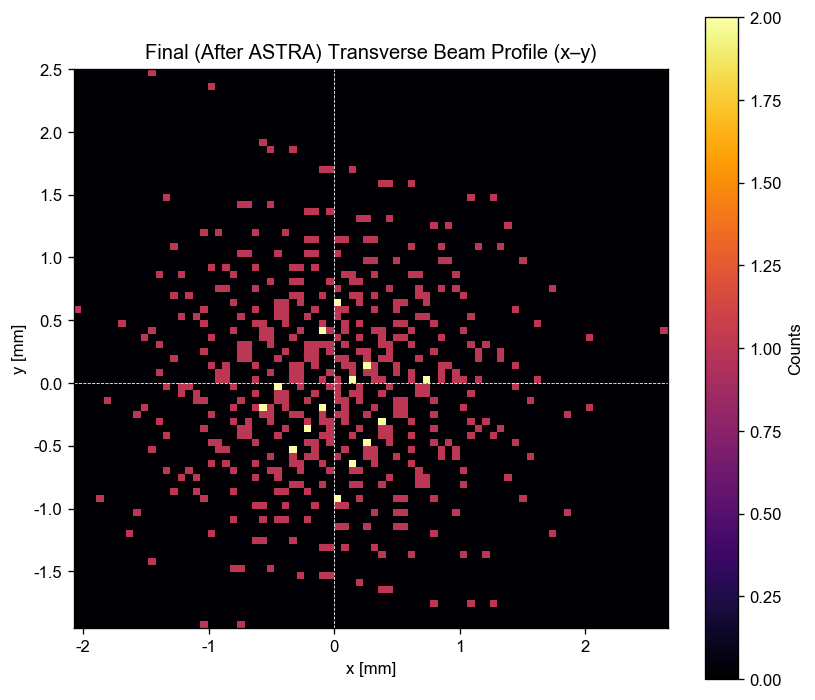

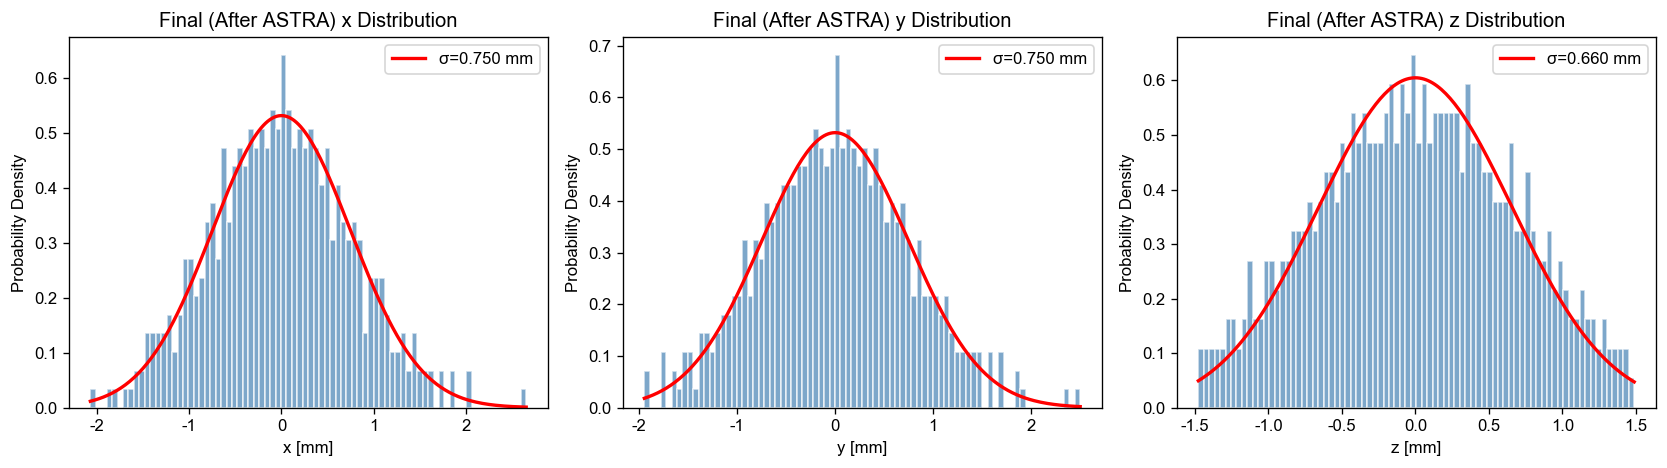

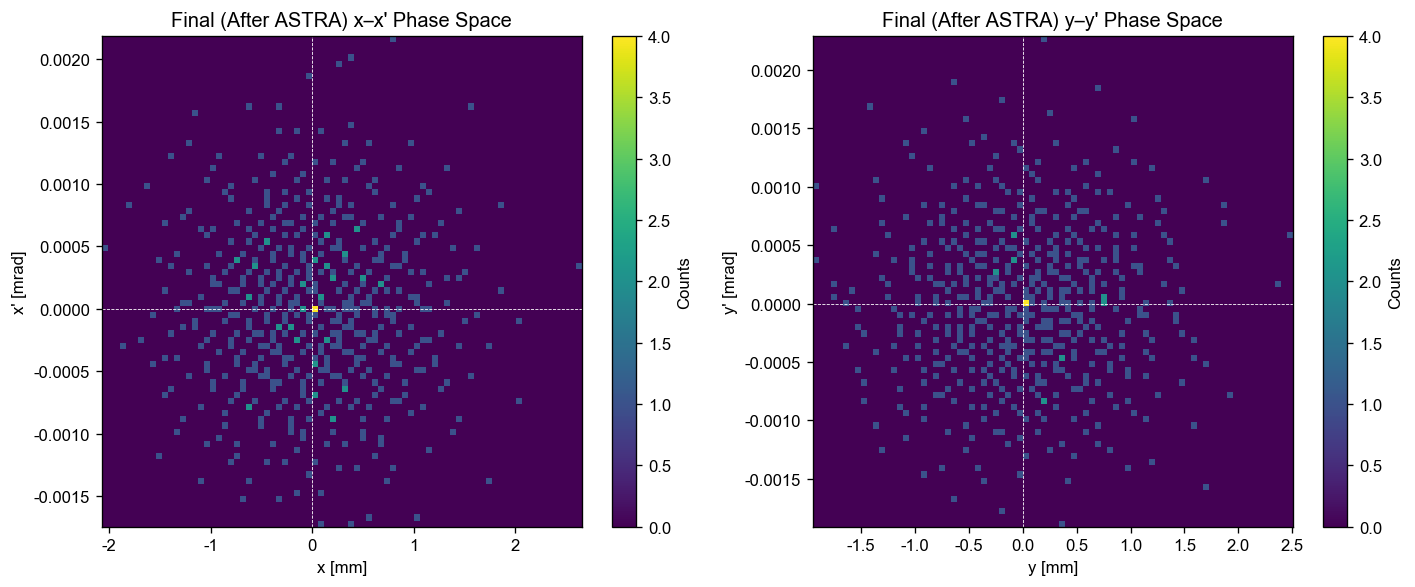

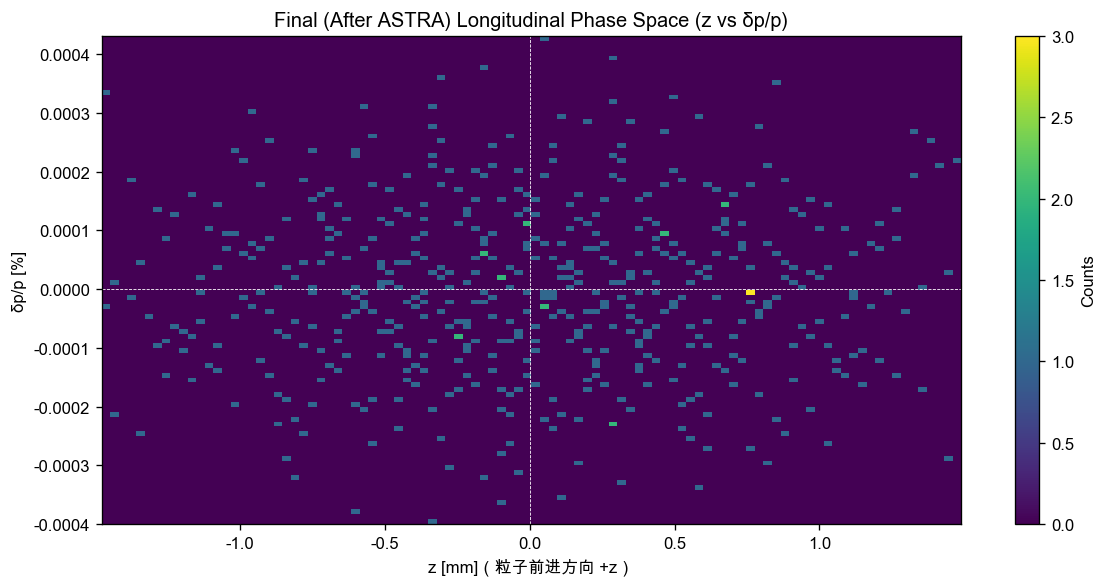

INFO: ASTRA 追踪后分析完成。


In [18]:
# 读取并解析 ASTRA 追踪输出的最终相空间

dist_final = utils.read_astra_distribution(ASTRA_OUTPUT_FILE)

# 显示基本信息
print(f"\nASTRA 追踪后束团概要：")
print(f"  粒子总数:       {dist_final['n_particle']}")
print(f"  活跃粒子数:     {dist_final['n_active']}")
print(f"  总电荷:         {dist_final['total_charge']:.4f} nC")
print(f"  丢失粒子数:     {dist_final['n_particle'] - dist_final['n_active']}")

# ---- 统计计算 ----
ref_eV = REF_ENERGY_MEV * 1e6 if REF_ENERGY_MEV is not None else None

stats_final = utils.compute_beam_statistics(
    dist_final,
    ref_energy_eV=ref_eV
)
utils.print_statistics(stats_final, title="最终束团统计 (ASTRA 追踪后)")

# ---- 绘图 ----
utils.logger.info("绘制追踪后束团相空间图...")
import matplotlib.pyplot as plt

# 图 1: 最终横向束斑 (x-y)
fig1 = utils.plot_transverse_scatter(dist_final, title_prefix="Final (After ASTRA)")
plt.show()

# 图 2: 最终 x, y, z 投影分布
fig2 = utils.plot_spatial_distributions(dist_final, title_prefix="Final (After ASTRA)")
plt.show()

# 图 3: 最终横向相空间 (x-x', y-y')
fig3 = utils.plot_transverse_phase_space(dist_final, title_prefix="Final (After ASTRA)")
plt.show()

# 图 4: 最终纵向相空间 (z vs δp/p)
fig4 = utils.plot_longitudinal_phase_space(dist_final, title_prefix="Final (After ASTRA)")
plt.show()

utils.logger.info("ASTRA 追踪后分析完成。")

## 初始 vs 最终对比（可选）

若你有初始分布文件，可在此加载并与追踪结果进行对比分析。
修改 `INITIAL_DIST_FILE` 为你的初始分布文件路径（设为 `None` 则跳过对比）。

In [19]:
# ---- 可选：初始 vs 最终对比分析 ----

# 设置初始分布文件路径（设为 None 跳过对比）
INITIAL_DIST_FILE = SIM_DIR / "bunch.ini"  # 默认使用与 ASTRA 相同的输入文件
# INITIAL_DIST_FILE = None  # 取消注释以跳过对比

ref_eV = REF_ENERGY_MEV * 1e6 if REF_ENERGY_MEV is not None else None

if INITIAL_DIST_FILE is not None and INITIAL_DIST_FILE.exists():
    import numpy as np
    import matplotlib.pyplot as plt
    
    utils.logger.info(f"加载初始分布文件: {INITIAL_DIST_FILE}")
    dist_initial = utils.read_astra_distribution(INITIAL_DIST_FILE)
    
    # 显示对比概要
    print(f"\n初始 -> 最终对比：")
    print(f"  初始电荷:       {dist_initial['total_charge']:.4f} nC")
    print(f"  最终电荷:       {dist_final['total_charge']:.4f} nC")
    print(f"  电荷损失:       {(dist_initial['total_charge'] - dist_final['total_charge']):.4f} nC")
    
    # 统计对比
    stats_initial = utils.compute_beam_statistics(
        dist_initial,
        ref_energy_eV=ref_eV
    )
    
    print(f"\n{'='*60}")
    print(f"  初始 -> 最终 关键参数变化")
    print(f"{'='*60}")
    print(f"  {'参数':<24s} {'初始':>15s} {'最终':>15s} {'变化':>15s}")
    print(f"  {'-'*69}")
    
    comparisons = [
        ("σ_x [mm]", "sig_x", 1e3),
        ("σ_y [mm]", "sig_y", 1e3),
        ("σ_z [mm]", "sig_z", 1e3),
        ("ε_x_geom [μm·rad]", "emit_x_geom", 1e6),
        ("ε_y_geom [μm·rad]", "emit_y_geom", 1e6),
        ("ε_nx [μm·rad]", "emit_x_norm", 1e6),
        ("ε_ny [μm·rad]", "emit_y_norm", 1e6),
        ("σ_E/E", "sig_E_over_E", 1),
    ]
    
    for label, key, scale in comparisons:
        init_val = stats_initial[key] * scale
        final_val = stats_final[key] * scale
        change = final_val - init_val
        change_pct = (change / init_val * 100) if init_val != 0 else 0.0
        print(f"  {label:<24s} {init_val:15.4f} {final_val:15.4f} {change:+.4f} ({change_pct:+.2f}%)")
    
    print(f"{'='*60}\n")
    
    # ---- 初始 vs 最终 叠加对比图 ----
    utils.logger.info("绘制初始 vs 最终对比图...")
    
    mask_i = dist_initial['active_mask']
    mask_f = dist_final['active_mask']
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # x 分布对比
    ax = axes[0, 0]
    ax.hist(dist_initial['x'][mask_i]*1e3, bins=60, density=True, alpha=0.5, label='Initial', color='blue')
    ax.hist(dist_final['x'][mask_f]*1e3, bins=60, density=True, alpha=0.5, label='Final', color='red')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('Density'); ax.set_title('x Distribution')
    ax.legend()
    
    # y 分布对比
    ax = axes[0, 1]
    ax.hist(dist_initial['y'][mask_i]*1e3, bins=60, density=True, alpha=0.5, label='Initial', color='blue')
    ax.hist(dist_final['y'][mask_f]*1e3, bins=60, density=True, alpha=0.5, label='Final', color='red')
    ax.set_xlabel('y [mm]'); ax.set_ylabel('Density'); ax.set_title('y Distribution')
    ax.legend()
    
    # z 分布对比
    ax = axes[0, 2]
    ax.hist(dist_initial['z'][mask_i]*1e3, bins=60, density=True, alpha=0.5, label='Initial', color='blue')
    ax.hist(dist_final['z'][mask_f]*1e3, bins=60, density=True, alpha=0.5, label='Final', color='red')
    ax.set_xlabel('z [mm]'); ax.set_ylabel('Density'); ax.set_title('z Distribution')
    ax.legend()
    
    # 能量分布对比 (pz)
    ax = axes[1, 0]
    ax.hist(dist_initial['pz'][mask_i]/1e6, bins=60, density=True, alpha=0.5, label='Initial', color='blue')
    ax.hist(dist_final['pz'][mask_f]/1e6, bins=60, density=True, alpha=0.5, label='Final', color='red')
    ax.set_xlabel('pz [MeV/c]'); ax.set_ylabel('Density'); ax.set_title('Momentum Distribution')
    ax.legend()
    
    # x-x' 对比
    ax = axes[1, 1]
    n_sample = min(2000, dist_initial['n_particle'])
    idx_i = np.random.choice(np.where(mask_i)[0], n_sample, replace=False)
    idx_f = np.random.choice(np.where(mask_f)[0], n_sample, replace=False)
    pz_i = np.abs(dist_initial['pz'][idx_i])
    pz_f = np.abs(dist_final['pz'][idx_f])
    xp_i = (dist_initial['px'][idx_i] / pz_i) * 1e3
    xp_f = (dist_final['px'][idx_f] / pz_f) * 1e3
    ax.scatter(dist_initial['x'][idx_i]*1e3, xp_i, s=1, alpha=0.4, label='Initial', color='blue')
    ax.scatter(dist_final['x'][idx_f]*1e3, xp_f, s=1, alpha=0.4, label='Final', color='red')
    ax.set_xlabel('x [mm]'); ax.set_ylabel("x' [mrad]"); ax.set_title("x–x' Phase Space")
    ax.legend()
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    
    # y-y' 对比
    ax = axes[1, 2]
    yp_i = (dist_initial['py'][idx_i] / pz_i) * 1e3
    yp_f = (dist_final['py'][idx_f] / pz_f) * 1e3
    ax.scatter(dist_initial['y'][idx_i]*1e3, yp_i, s=1, alpha=0.4, label='Initial', color='blue')
    ax.scatter(dist_final['y'][idx_f]*1e3, yp_f, s=1, alpha=0.4, label='Final', color='red')
    ax.set_xlabel('y [mm]'); ax.set_ylabel("y' [mrad]"); ax.set_title("y–y' Phase Space")
    ax.legend()
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    
    plt.suptitle('Initial vs Final Beam Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    utils.logger.info("初始 vs 最终对比完成。")
else:
    utils.logger.info("跳过初始 vs 最终对比（初始分布文件未找到或未设置）。")

INFO: 跳过初始 vs 最终对比（初始分布文件未找到或未设置）。


## Summary

详细使用说明和参数列表参见 `README.md`。

- 生成的文件均在 `SIM_DIR`（默认 `simulation_files/`）下
- 若要更换初始分布，修改上方 `DISTRIBUTION_FILE` 变量并重新运行
- 若要多次运行不覆盖，修改 `astra_newrun_params` 中的 `RUN` 编号

In [20]:
# 附录：查看 simulation_files/ 中的生成文件

print(f"SIM_DIR: {SIM_DIR}")
print(f"\n生成的文件列表：")
print(f"{'文件名':<30s} {'大小 (bytes)':>15s} {'修改时间':>25s}")
print("-" * 72)
for f in sorted(SIM_DIR.iterdir()):
    if f.is_file():
        stat = f.stat()
        from datetime import datetime
        mtime = datetime.fromtimestamp(stat.st_mtime).strftime('%Y-%m-%d %H:%M:%S')
        print(f"{f.name:<30s} {stat.st_size:>15,d} {mtime:>25s}")

print(f"\n提示：要清理输出文件，运行:")
print(f"  import shutil")
print(f"  shutil.rmtree(SIM_DIR)  # 删除工作目录")

SIM_DIR: /Users/yuxinwu/astra_notebook/simulation_files

生成的文件列表：
文件名                                 大小 (bytes)                      修改时间
------------------------------------------------------------------------
3_cell_L-Band.dat                       15,991       2026-07-06 01:04:44
Example.0010.001                        52,500       2026-07-06 01:13:41
Example.0020.001                        52,500       2026-07-06 01:13:41
Example.0050.001                        52,500       2026-07-06 01:14:04
Example.0100.001                        52,500       2026-07-06 01:14:04
Example.0150.001                        52,500       2026-07-06 01:14:05
Example.Log.001                         16,092       2026-07-06 01:14:05
Example.Sigma.001                      196,784       2026-07-06 01:14:05
Example.Xemit.001                       42,670       2026-07-06 01:14:05
Example.Yemit.001                       42,670       2026-07-06 01:14:05
Example.Zemit.001                       42,670       2026-